<a href="https://colab.research.google.com/github/Gaurav-Rajawat/Pneumonia_detector_model/blob/main/Pneumonia_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
chest-xray-pneumonia.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
!unzip chest-xray-pneumonia.zip

Archive:  chest-xray-pneumonia.zip
replace chest_xray/__MACOSX/._chest_xray? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace chest_xray/__MACOSX/chest_xray/._.DS_Store? [y]es, [n]o, [A]ll, [N]one, [r]ename: N
N


In [ ]:
!pip install tensorflow

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications import DenseNet121

from tensorflow.keras import Sequential

In [ ]:
### dataset paths
train_dt = '/content/chest_xray/train'
test_dt = '/content/chest_xray/test'
val_dt = '/content/chest_xray/val'


In [ ]:
### loading dataset and generators
# train_ds = tf.keras.utils.image_dataset_from_directory(
#     train_dt,
#     label_mode='binary',
#     validation_split=0.2,
#     seed = 42,
#     subset='training',
#     image_size=(224, 224),
#     batch_size=32
# )
# test_ds = tf.keras.utils.image_dataset_from_directory(
#     test_dt,
#     label_mode='binary',
#     image_size=(224, 224),
#     batch_size=32
# )
# val_ds = tf.keras.utils.image_dataset_from_directory(
#     train_dt,
#     label_mode='binary',
#     subset='validation',
#     seed = 42,
#     valdation_split=0.2,
#     image_size=(224, 224),
#     batch_size=32
# ) ########## for model 1 with accuracy 85 for better accuracy ###############
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dt,
    validation_split=0.2,
    subset="training",
    seed=42,
    label_mode="binary",
    image_size=(224,224),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dt,
    validation_split=0.2,
    subset="validation",
    seed=42,
    label_mode="binary",
    image_size=(224,224),
    batch_size=32
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dt,
    label_mode="binary",
    image_size=(224,224),
    batch_size=32
)
### here we create validation dataset from training dataset

Found 5216 files belonging to 2 classes.
Using 4173 files for training.
Found 5216 files belonging to 2 classes.
Using 1043 files for validation.
Found 624 files belonging to 2 classes.


In [ ]:
# Performance optimization
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

In [ ]:
# Data Augmentation
data_aug = tf.keras.Sequential([
    layers.RandomRotation(0.2),
    layers.RandomShear(0.2),
    layers.RandomZoom(0.2),
    layers.RandomFlip('Horizontal')
])

In [ ]:
## pretrained model
base_model = DenseNet121(
    weights = 'imagenet',
    input_shape = (224, 224, 3),
    include_top = False
)
base_model.trainable = False

In [ ]:
model = Sequential([
    data_aug,
    layers.Rescaling(1./255), # normalizing the image
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
])

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

Epoch 1/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 64s 320ms/step - accuracy: 0.8569 - loss: 0.3159 - val_accuracy: 0.9147 - val_loss: 0.2069
Epoch 2/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 38s 293ms/step - accuracy: 0.9176 - loss: 0.2104 - val_accuracy: 0.9041 - val_loss: 0.2383
Epoch 3/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 43s 327ms/step - accuracy: 0.9212 - loss: 0.1910 - val_accuracy: 0.8869 - val_loss: 0.2867
Epoch 4/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 38s 291ms/step - accuracy: 0.9250 - loss: 0.1815 - val_accuracy: 0.9473 - val_loss: 0.1465
Epoch 5/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 41s 292ms/step - accuracy: 0.9272 - loss: 0.1835 - val_accuracy: 0.9012 - val_loss: 0.2394
Epoch 6/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 38s 273ms/step - accuracy: 0.9283 - loss: 0.1741 - val_accuracy: 0.9118 - val_loss: 0.2122
Epoch 7/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 47s 357ms/step - accuracy: 0.9322 - loss: 0.1639 - val_accuracy: 0.9012 - val_loss: 0.2319
Epoch 8/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 70s 264ms/step - accuracy: 0.9315 - loss: 0

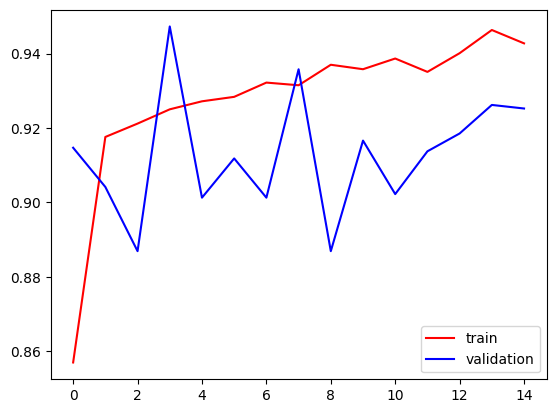

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], color = 'red', label = 'train')
plt.plot(history.history['val_accuracy'], color = 'blue', label = 'validation')
plt.legend()
plt.show()

In [ ]:
loss, acc = model.evaluate(test_ds)

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 229ms/step - accuracy: 0.8734 - loss: 0.3262


In [ ]:
model.save("pneumonia_detector.h5")


In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,431,493 (28.35 MB)

 Trainable params: 131,329 (513.00 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

 Optimizer params: 262,660 (1.00 MB)

In [ ]:
import tensorflow as tf
import numpy as np

# model = tf.keras.models.load_model("pneumonia_detector.h5")

img = tf.keras.utils.load_img(
    "sample_xray.jpeg",
    target_size=(224,224)
)

img_array = tf.keras.utils.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

prediction = model.predict(img_array)

if prediction[0][0] > 0.5:
    print("PNEUMONIA")
else:
    print("NORMAL")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
PNEUMONIA


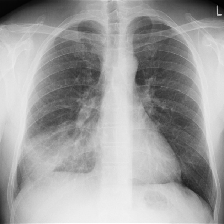

In [ ]:
img

In [ ]:
model.save("pneumonia.keras")